# Channel Exploration — YouTube ↔ Material local

**Flujo:**
1. Setup
2. Fetch catálogo desde múltiples playlists de YouTube
3. Stats por playlist
4. Comparación YouTube ↔ MOV locales (SharePoint)

## 1. Setup

In [ ]:
import sys
import re
import unicodedata
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, '../scripts')
from fetch_channel_catalog import load_config, build_catalog, save_catalog, load_catalog
from analyze_raw import scan_folder
import yaml

with open('../config.yaml') as f:
    config = yaml.safe_load(f)

RAW_DIR = Path(config['paths']['videos'])

print('Config loaded')
print(f'  catalog path: {config["catalog"]["path"]}')
print(f'  videos:       {RAW_DIR}')
print(f'  existe:       {RAW_DIR.exists()}')

Config loaded
  catalog path: data/catalog
  videos:       /mnt/c/Users/mdp_e/Gobierno de la Ciudad de Buenos Aires/grupo_DG Inclusión Digital - Documents/02-Proyectos/08-Avatar AI/Material LSA/GUÍA INFO LSA 2018-2019/videos
  existe:       True


---
## 2. Fetch catálogo

Pegá todas las URLs de playlists del canal en `PLAYLIST_URLS` y corré la celda.
Acepta URL de canal, de playlist, o de video — yt-dlp las resuelve todas.

In [ ]:
# ── Pegá acá las URLs de las playlists ────────────────────────────────────────
PLAYLIST_URLS = [
   "https://www.youtube.com/watch?v=ook_O5pd3D0&list=PLbwR2bewXC0vkIo1Z-bXUd6hX4-e84z3-",
   "https://www.youtube.com/watch?v=u07hL-EzTpY&list=PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8",
   "https://www.youtube.com/watch?v=KrAliLan0Gs&list=PLbwR2bewXC0t0GyilL9PCNLZ9UkLgH15n",
   "https://www.youtube.com/watch?v=kMOBrkojQbw&list=PLbwR2bewXC0uZ5Dg0NcYQfXOZLfxhlzqZ",
   "https://www.youtube.com/watch?v=J6xUFDqW4BA&list=PLbwR2bewXC0vB4SzXaX9z9NX3QzO1nbvo",
   "https://www.youtube.com/watch?v=wSd8jKV42Y8&list=PLbwR2bewXC0v36CHFDw5ykOz2yBI3FMzw",
   "https://www.youtube.com/watch?v=vdp9Fh7jj-8&list=PLbwR2bewXC0tqaY9KgL_XOVsaks161SI3",
   "https://www.youtube.com/watch?v=ZbjWSR5fl88&list=PLbwR2bewXC0s_msOAClKPM_FwldLpb9uj",
   "https://www.youtube.com/watch?v=0Vxf04VftJE&list=PLbwR2bewXC0utietGdTV6UT288cpqyoxW",
   "https://www.youtube.com/watch?v=dzQ8_c5glyA&list=PLbwR2bewXC0skJ3P8MkJjslIl1Fj_7tMn",
   "https://www.youtube.com/watch?v=bw6hm44CRQk&list=PLbwR2bewXC0uToGt3-2rfnOJG9_2n9XJ2",
   "https://www.youtube.com/watch?v=qxy6Wv4NRB4&list=PLbwR2bewXC0tTBXdYOFD2eeIjf4rT3dCZ"
]
# ─────────────────────────────────────────────────────────────────────────────

if not PLAYLIST_URLS:
    raise ValueError("Agregá al menos una URL en PLAYLIST_URLS")

from datetime import datetime, timezone

all_playlists  = []
seen_video_ids = set()

for url in PLAYLIST_URLS:
    print(f'\nFetching: {url}')
    partial = build_catalog(url, config, existing=load_catalog(config))
    for pl in partial['playlists']:
        unique = [v for v in pl['videos'] if v['video_id'] not in seen_video_ids]
        seen_video_ids.update(v['video_id'] for v in unique)
        pl['videos']   = unique
        pl['n_videos'] = len(unique)
        all_playlists.append(pl)

catalog = {
    'channel_url': PLAYLIST_URLS[0],
    'fetched_at':  datetime.now(timezone.utc).isoformat(),
    'playlists':   all_playlists,
}
save_catalog(catalog, config)

total = sum(pl['n_videos'] for pl in catalog['playlists'])
print(f"\n{'='*45}")
print(f"Playlists: {len(catalog['playlists'])}")
print(f"Videos:    {total}")
print(f"{'='*45}")


Fetching: https://www.youtube.com/watch?v=ook_O5pd3D0&list=PLbwR2bewXC0vkIo1Z-bXUd6hX4-e84z3-
Fetching channel metadata: https://www.youtube.com/watch?v=ook_O5pd3D0&list=PLbwR2bewXC0vkIo1Z-bXUd6hX4-e84z3-
  Playlist: Guía de Turismo 2018/2019
    [skip] ook_O5pd3D0 (already cataloged)
    [skip] VlfX8oURh-s (already cataloged)
    [skip] q4S4J59Dvr8 (already cataloged)
    [skip] nbHsyDeo3Eo (already cataloged)
    [skip] QG7ND5YNfVQ (already cataloged)
    [skip] 7az9Z92XonA (already cataloged)
    [skip] EGxhVpFU1OI (already cataloged)
    [skip] bg8ySVMa71A (already cataloged)

Fetching: https://www.youtube.com/watch?v=u07hL-EzTpY&list=PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8
Fetching channel metadata: https://www.youtube.com/watch?v=u07hL-EzTpY&list=PLbwR2bewXC0sAjOMh7rEq7Blw6D1Y8OU8
  Playlist: Guia de Información 2018/2019 | Servicios Sociales Zonales
    [skip] u07hL-EzTpY (already cataloged)
    [skip] T_vgQJhMWf8 (already cataloged)
    [skip] 2iYRa7hKg2g (already cataloged)

Fetch

---
## 3. Stats por playlist

In [24]:
rows = []
for pl in catalog['playlists']:
    for v in pl['videos']:
        rows.append({'playlist_title': pl['playlist_title'], 'playlist_id': pl['playlist_id'], **v})

df = pd.DataFrame(rows)
print(f'Total videos en catálogo: {len(df)}')
df[['playlist_title','title','duration_sec','video_id']].head(10)

Total videos en catálogo: 67


,playlist_title,title,duration_sec,video_id
0,Guía de Turismo 2018/2019,Circuito 1: San Nicolás / Casco Histórico,222,ook_O5pd3D0
1,Guía de Turismo 2018/2019,Circuito 2: San Telmo / La Boca,276,VlfX8oURh-s
2,Guía de Turismo 2018/2019,Circuito 3: Recoleta / Retiro,190,q4S4J59Dvr8
3,Guía de Turismo 2018/2019,Circuito 4: Puerto Madero / Balvanera,270,nbHsyDeo3Eo
4,Guía de Turismo 2018/2019,Circuito 5: Palermo / Belgrano,196,QG7ND5YNfVQ
5,Guía de Turismo 2018/2019,Circuito 6: Provincia de Buenos Aires - La Plata,66,7az9Z92XonA
6,Guía de Turismo 2018/2019,Circuito 7: Provincia de Buenos Aires / Bahía ...,59,EGxhVpFU1OI
7,Guía de Turismo 2018/2019,Circuito 8 y 9: Provincia de Buenos Aires/ Mar...,60,bg8ySVMa71A
8,Guia de Información 2018/2019 | Servicios Soci...,1. Programa Hogares,52,u07hL-EzTpY
9,Guia de Información 2018/2019 | Servicios Soci...,2. Apoyos del Gobierno de la Nación,44,T_vgQJhMWf8


Stats por playlist
                                                         playlist_title  n_videos  total_min  avg_s
             Guia de Información 2018/2019 | Servicios Sociales Zonales         3        2.1   42.3
                          Guía de Información 2018/2019 | Accesibilidad         6        4.6   46.5
                    Guía de Información 2018/2019 | Beneficios Fiscales         2        0.4   13.0
Guía de Información 2018/2019 | Certificado Único de Discapacidad - CUD         8        5.6   41.9
                              Guía de Información 2018/2019 | Educación         7        4.6   39.0
                          Guía de Información 2018/2019 | Participación         2        1.2   37.5
                                  Guía de Información 2018/2019 | Salud         7        4.2   36.1
                    Guía de Información 2018/2019 | Sistema Previsional        11        5.4   29.5
                                Guía de Información 2018/2019 | Trabajo         5

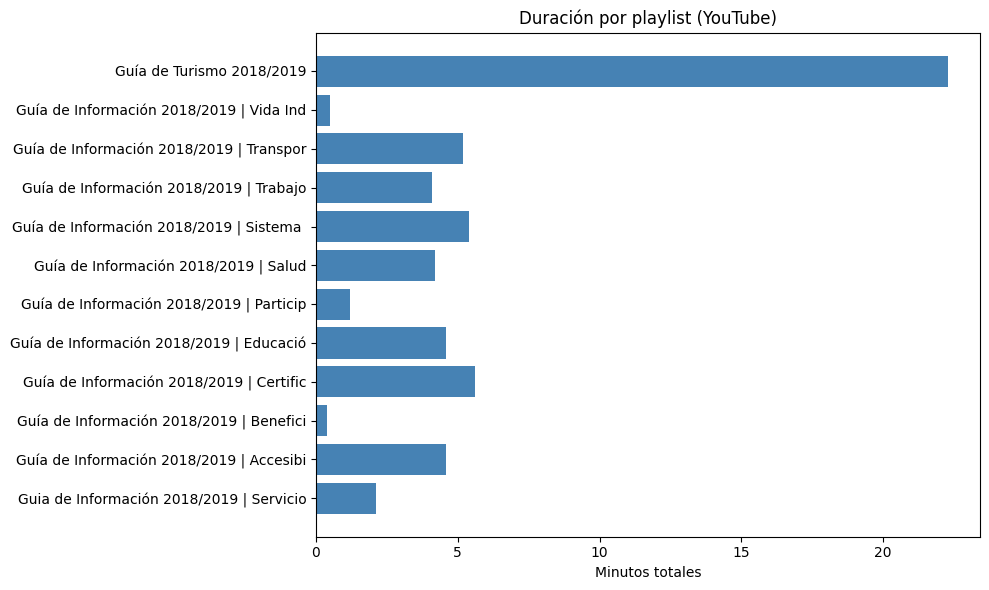

In [25]:
def _modal(s):
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else None

stats = df.groupby('playlist_title').agg(
    n_videos   = ('video_id',    'count'),
    total_min  = ('duration_sec', lambda x: round(x.sum() / 60, 1)),
    avg_s      = ('duration_sec', lambda x: round(x.mean(), 1)),
).reset_index()

print('Stats por playlist')
print(stats.to_string(index=False))
print(f'\nTotal: {stats.n_videos.sum()} videos — {stats.total_min.sum():.1f} min')

fig, ax = plt.subplots(figsize=(10, max(3, len(stats)*0.5)))
ax.barh(stats.playlist_title.str[:40], stats.total_min, color='steelblue')
ax.set_xlabel('Minutos totales')
ax.set_title('Duración por playlist (YouTube)')
plt.tight_layout()
plt.show()

---
## 4. Comparación YouTube ↔ Material local

Matching por **duración** (55%) + **keywords** enriquecidos con subtítulos del DOCX (45%).  
Score 0–1. Threshold por defecto: 0.35.

In [26]:
import warnings; warnings.filterwarnings('ignore')
from parse_subs_docx import parse_subs_docx

print('Escaneando MOV locales...')
local_metas = scan_folder(RAW_DIR)
local = [m for m in local_metas if m.readable]

subs = parse_subs_docx(Path('../data/raw/GUÍA INFO LSA 2018-2019/Guia Subs.docx'))
sub_by_num = {s.video_num: s.text for s in subs}

yt_videos = [
    {**v, 'playlist_title': pl['playlist_title']}   # nombre completo, sin truncar
    for pl in catalog['playlists']
    for v in pl['videos']
]

print(f'YouTube: {len(yt_videos)} videos')
print(f'Local:   {len(local)} MOV')
print(f'Subs DOCX: {len(sub_by_num)}')

STOP = {
    'de','la','el','en','y','a','que','es','los','las','se','con','para',
    'un','una','por','del','al','como','si','lsa','guia','informacion',
    'puede','pueden','tiene','tienen','hay','ser','podes','esta','esto',
    'persona','personas','discapacidad','ciudad','buenos','aires',
}

def tokenize(text):
    text = text.lower()
    text = ''.join(c for c in unicodedata.normalize('NFD', text)
                   if unicodedata.category(c) != 'Mn')
    return {t for t in re.findall(r'[a-z]+', text)
            if t not in STOP and len(t) > 3}

def dur_score(a, b):
    if not a or not b or b == 0:
        return 0.0
    return round(min(a, b) / max(a, b), 3)

def kw_score(title, local_tokens):
    a = tokenize(title)
    if not a or not local_tokens:
        return 0.0
    return round(len(a & local_tokens) / len(a | local_tokens), 3)

local_tokens = {}
for lm in local:
    tokens = tokenize(lm.filename)
    if lm.video_num and lm.video_num in sub_by_num:
        tokens |= tokenize(sub_by_num[lm.video_num])
    local_tokens[lm.filename] = tokens

DUR_THRESHOLD   = 0.70
SCORE_THRESHOLD = 0.35

used_local = set()
matches    = []

for yt in yt_videos:
    candidates = []
    for lm in local:
        d = dur_score(yt.get('duration_sec'), lm.duration_s)
        if d < DUR_THRESHOLD:
            continue
        k = kw_score(yt['title'], local_tokens[lm.filename])
        s = round(0.55 * d + 0.45 * k, 3)
        candidates.append((s, d, k, lm))

    candidates.sort(key=lambda x: -x[0])
    if candidates and candidates[0][0] >= SCORE_THRESHOLD \
            and candidates[0][3].filename not in used_local:
        s, d, k, best = candidates[0]
        used_local.add(best.filename)
        matches.append({
            'yt_id':          yt['video_id'],
            'yt_title':       yt['title'],
            'yt_dur_s':       yt.get('duration_sec'),
            'playlist':       yt['playlist_title'],   # nombre completo
            'local_file':     best.filename,
            'local_dur_s':    best.duration_s,
            'has_sub':        best.video_num in sub_by_num if best.video_num else False,
            'dur_score':      d,
            'kw_score':       k,
            'score':          s,
            'match':          'OK',
        })
    else:
        matches.append({
            'yt_id':          yt['video_id'],
            'yt_title':       yt['title'],
            'yt_dur_s':       yt.get('duration_sec'),
            'playlist':       yt['playlist_title'],
            'local_file':     None, 'local_dur_s': None, 'has_sub': False,
            'dur_score':      0,    'kw_score':    0,    'score':   0,
            'match':          'SIN MATCH',
        })

df_match      = pd.DataFrame(matches).sort_values(['match','score'], ascending=[True, False])
matched_files = {m['local_file'] for m in matches if m['match'] == 'OK'}
unmatched_loc = [lm for lm in local if lm.filename not in matched_files]

ok_kw = (df_match[df_match.match=='OK'].kw_score > 0).sum()
print(f"\nYouTube con match local:   {(df_match.match=='OK').sum()}")
print(f"  — con overlap keywords:  {ok_kw}")
print(f"YouTube SIN match local:   {(df_match.match=='SIN MATCH').sum()}")
print(f"MOV locales SIN match YT:  {len(unmatched_loc)}")

Escaneando MOV locales...
  [01/75] DSC_0700 Titulo CUD.MOV
  [02/75] DSC_0701 Titulo Sistema Prev.MOV
  [03/75] DSC_0702 Titulo Salud Transp Acc.MOV
  [04/75] DSC_0703 Titulo SSZonales (ver).MOV
  [05/75] DSC_0704 Titulo Beneficios Fisc (ver).MOV
  [06/75] DSC_0705 Titulo Educacion.MOV
  [07/75] DSC_0707 Titulo Vida Indep2 si NO SE USA.MOV
  [08/75] DSC_0710 CUD3 si (ver).MOV
  [09/75] DSC_0715 PCD5 si.MOV
  [10/75] DSC_0718 CUD tram3 no c.MOV
  [11/75] DSC_0719 CUD tram4 si.MOV
  [12/75] DSC_0724 CUD uso5 si.MOV
  [13/75] DSC_0726 salud2 si.MOV
  [14/75] DSC_0730 transp4 ver.MOV
  [15/75] DSC_0731 CUD dnd si.MOV
  [16/75] DSC_0735 BF3 si.MOV
  [17/75] DSC_0737 Apoyo2 primera parte.MOV
  [18/75] DSC_0738 Apoyo3 final.MOV
  [19/75] DSC_0740 CUD tramite1si.MOV
  [20/75] DSC_0741 CUD tramite2 si.MOV
  [21/75] DSC_0746 CUD pierde si.MOV
  [22/75] DSC_0747 Sist Prev si.MOV
  [23/75] DSC_0748 PNC1.MOV
  [24/75] DSC_0749 PNC2.MOV
  [25/75] DSC_0760 PNC quien si.MOV
  [26/75] DSC_0761 PNC dnd

In [27]:
print('MATCHES OK')
print('=' * 100)
ok = df_match[df_match.match == 'OK'][['yt_title','yt_dur_s','local_file','local_dur_s','dur_score','kw_score','score']]
print(ok.assign(yt_title=ok.yt_title.str[:35], local_file=ok.local_file.str[:35]).to_string(index=False))

print()
print('YOUTUBE SIN MATCH LOCAL')
print('=' * 70)
nm = df_match[df_match.match == 'SIN MATCH'][['yt_title','yt_dur_s','playlist']]
if len(nm):
    print(nm.assign(yt_title=nm.yt_title.str[:55]).to_string(index=False))
else:
    print('  (ninguno)')

print()
print('MOV LOCALES SIN MATCH EN YOUTUBE')
print('=' * 70)
if unmatched_loc:
    for lm in unmatched_loc:
        print(f'  {lm.filename[:55]:55s}  {lm.duration_s:.1f}s  {lm.flags}')
else:
    print('  (ninguno)')

MATCHES OK
                           yt_title  yt_dur_s                          local_file  local_dur_s  dur_score  kw_score  score
           11. Retiro por invalidez        33              DSC_0785 Retiro si.MOV        34.53      0.956     0.500  0.751
3. ¿Cuándo podes cobrar la pensión         39       DSC_0773 Pension fliar si.MOV        45.15      0.864     0.250  0.588
                1. Apoyos Educación        40 DSC_0873 p.87 que apoyos te da el M        40.14      0.997     0.087  0.588
3.  Pedir prestaciones básicas de s        37   DSC_0792 Serv Salud basico si.MOV        40.04      0.924     0.167  0.583
5. Centros educativos de atención y        37   DSC_0737 Apoyo2 primera parte.MOV        35.74      0.966     0.111  0.581
    1. Registro Único Laboral - RUL        68          DSC_1031pquenos com si.MOV        67.97      1.000     0.057  0.576
       5. Guía de Turismo Accesible        52                   DSC_0847 p.69.MOV        54.15      0.960     0.091  0.569
6. ¿C

Guardado: ../data/catalog/yt_vs_local_matching.csv


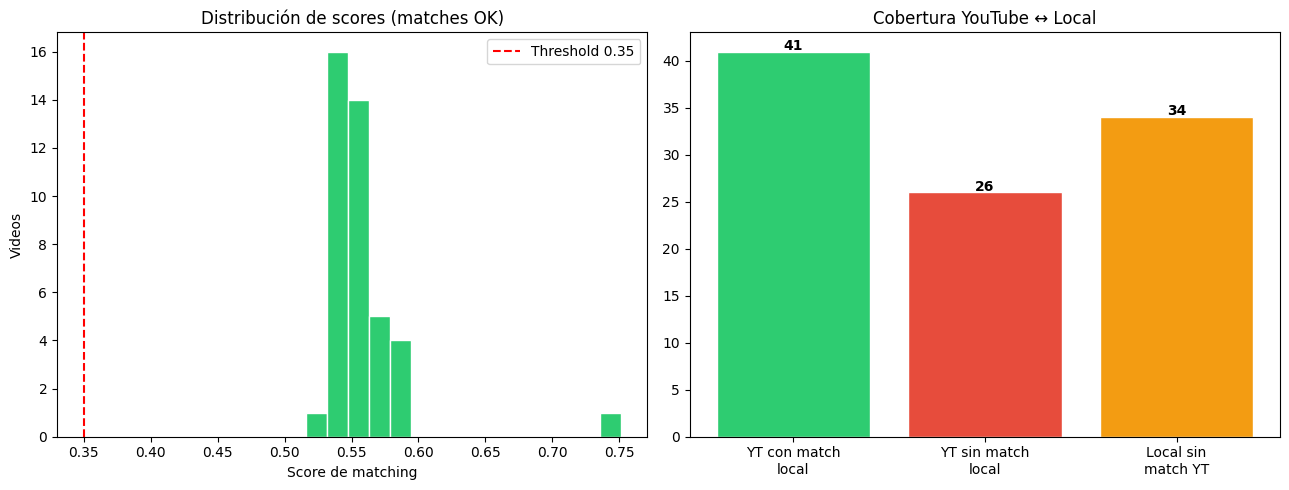

In [28]:
out = Path('../data/catalog/yt_vs_local_matching.csv')
df_match.to_csv(out, index=False, encoding='utf-8')
print(f'Guardado: {out}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ok_scores = df_match[df_match.match == 'OK'].score
if len(ok_scores):
    axes[0].hist(ok_scores, bins=15, color='#2ecc71', edgecolor='white')
    axes[0].axvline(SCORE_THRESHOLD, color='red', linestyle='--', label=f'Threshold {SCORE_THRESHOLD}')
    axes[0].set_xlabel('Score de matching')
    axes[0].set_ylabel('Videos')
    axes[0].set_title('Distribución de scores (matches OK)')
    axes[0].legend()

cats   = ['YT con match\nlocal', 'YT sin match\nlocal', 'Local sin\nmatch YT']
vals   = [(df_match.match=='OK').sum(), (df_match.match=='SIN MATCH').sum(), len(unmatched_loc)]
colors = ['#2ecc71', '#e74c3c', '#f39c12']
axes[1].bar(cats, vals, color=colors, edgecolor='white')
axes[1].set_title('Cobertura YouTube ↔ Local')
for i, v in enumerate(vals):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()